# Feature Engineering

In [50]:
import os
import joblib
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, FunctionTransformer
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, f1_score, make_scorer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split

In [33]:
DATA_DIR = r"D:\Ameng\Data Science Project\heart-failure-prediction\data"

df = pd.read_csv(
    os.path.join(
        DATA_DIR,
        "heart_failure_clinical_records_dataset.csv"
    )
)

X = df.drop("DEATH_EVENT", axis=1)
y = df["DEATH_EVENT"]

In [34]:
df.head()

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
0,75.0,0,582,0,20,1,265000.00,1.9,130,1,0,4,1
1,55.0,0,7861,0,38,0,263358.03,1.1,136,1,0,6,1
2,65.0,0,146,0,20,0,162000.00,1.3,129,1,1,7,1
3,50.0,1,111,0,20,0,210000.00,1.9,137,1,0,7,1
4,65.0,1,160,1,20,0,327000.00,2.7,116,0,0,8,1


In [35]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

print("Train shape:", X_train.shape)
print("Test shape :", X_test.shape)

Train shape: (239, 12)
Test shape : (60, 12)


In [36]:
def add_egfr(df_new):
    df_new = df_new.copy()
    scr, age, sex = df_new["serum_creatinine"], df_new["age"], df_new["sex"]
    k = np.where(sex == 0, 0.7, 0.9)
    alpha = np.where(sex == 0, -0.241, -0.302)
    df_new["egfr"] = (142 * np.minimum(scr / k, 1.0) ** alpha * np.maximum(scr / k, 1.0) ** -1.200 * 0.9938 ** age)
    return df_new

def add_ef_group(df_new):
    df_new = df_new.copy()
    df_new["ef_group"] = np.where(df_new["ejection_fraction"] < 40, 0, np.where(df_new["ejection_fraction"] <= 49, 1, 2))
    return df_new

In [37]:
X_train_fe = add_ef_group(add_egfr(X_train))

print("eGFR range:", X_train_fe["egfr"].min().round(1), "-", X_train_fe["egfr"].max().round(1))
print("\nef_group distribution:")
print(X_train_fe["ef_group"].value_counts().sort_index())

eGFR range: 4.7 - 118.0

ef_group distribution:
ef_group
0    144
1     47
2     48
Name: count, dtype: int64


In [38]:
X_train_fe[["age", "serum_creatinine", "sex", "ejection_fraction", "egfr", "ef_group"]].head()

,age,serum_creatinine,sex,ejection_fraction,egfr,ef_group
115,58.0,1.0,0,40,64.527903,1
23,53.0,0.8,1,60,105.823715,2
0,75.0,1.9,1,20,36.332850,0
247,64.0,2.4,1,25,29.394182,0
194,45.0,1.6,1,20,53.813351,0


## Feature Engineering Evaluation

In [39]:
base_features = X_train.columns.tolist()
egfr_features = base_features + ["egfr"]
ef_group_features = base_features + ["ef_group"]
all_fe_features = base_features + ["egfr", "ef_group"]

In [40]:
def build_preprocesor(feature_set):
    log_cols = ["creatinine_phosphokinase", "serum_creatinine", "platelets", "time"]
    scale_cols = ["age", "ejection_fraction", "serum_sodium"]
    bin_cols = ["anaemia", "diabetes", "high_blood_pressure", "sex", "smoking"]

    if "egfr" in feature_set:
        log_cols.append("egfr")

    if "ef_group" in feature_set:
        bin_cols.append("ef_group")

    log_pipeline = Pipeline([
        ("log", FunctionTransformer(np.log1p, feature_names_out="one-to-one")),
        ("scale", StandardScaler())
    ])
    
    scale_pipeline = Pipeline([
        ("scale", StandardScaler())
    ])

    return ColumnTransformer([
        ("log", log_pipeline, log_cols),
        ("scale", scale_pipeline, scale_cols),
        ("pass", "passthrough", bin_cols)
    ])

In [41]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

models = {
    "Logistic Regression": LogisticRegression(
        class_weight="balanced",
        max_iter=1000,
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        class_weight="balanced",
        random_state=42,
        n_estimators=300
    )
}

In [42]:
def evaluate_feature_set(X_data, feature_set, model):
    preprocessor = build_preprocesor(feature_set)
    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    roc_auc_scores = cross_val_score(pipeline, X_data[feature_set], y_train, cv=cv, scoring="roc_auc")
    f1_scores = cross_val_score(pipeline, X_data[feature_set], y_train, cv=cv, scoring="f1")

    return {
        "ROC-AUC Mean": roc_auc_scores.mean(),
        "ROC-AUC Std": roc_auc_scores.std(),
        "F1 Mean": f1_scores.mean(),
        "F1 Std": f1_scores.std()
    }

In [43]:
feature_sets = {
    "Baseline": base_features,
    "Baseline + eGFR": egfr_features,
    "Baseline + EF Group": ef_group_features,
    "Baseline + eGFR + EF Group": all_fe_features
}

In [44]:
results = []

for feature_name, feature_set in feature_sets.items():
    for model_name, model in models.items():
        scores = evaluate_feature_set(
            X_train_fe,
            feature_set,
            model
        )

        results.append({
            "Feature Set": feature_name,
            "Model": model_name,
            **scores
        })

results_df = pd.DataFrame(results)

In [49]:
results_df.round(4).sort_values("ROC-AUC Mean", ascending=False)

,Feature Set,Model,ROC-AUC Mean,ROC-AUC Std,F1 Mean,F1 Std
4,Baseline + EF Group,Logistic Regression,0.9095,0.0188,0.7716,0.0558
1,Baseline,Random Forest,0.9081,0.0149,0.7395,0.0573
0,Baseline,Logistic Regression,0.9066,0.0198,0.7882,0.0501
6,Baseline + eGFR + EF Group,Logistic Regression,0.9062,0.0192,0.7616,0.0442
2,Baseline + eGFR,Logistic Regression,0.9057,0.0216,0.7850,0.0383
5,Baseline + EF Group,Random Forest,0.9051,0.0075,0.7365,0.0499
7,Baseline + eGFR + EF Group,Random Forest,0.9046,0.0127,0.7580,0.0414
3,Baseline + eGFR,Random Forest,0.8965,0.0149,0.7385,0.0492


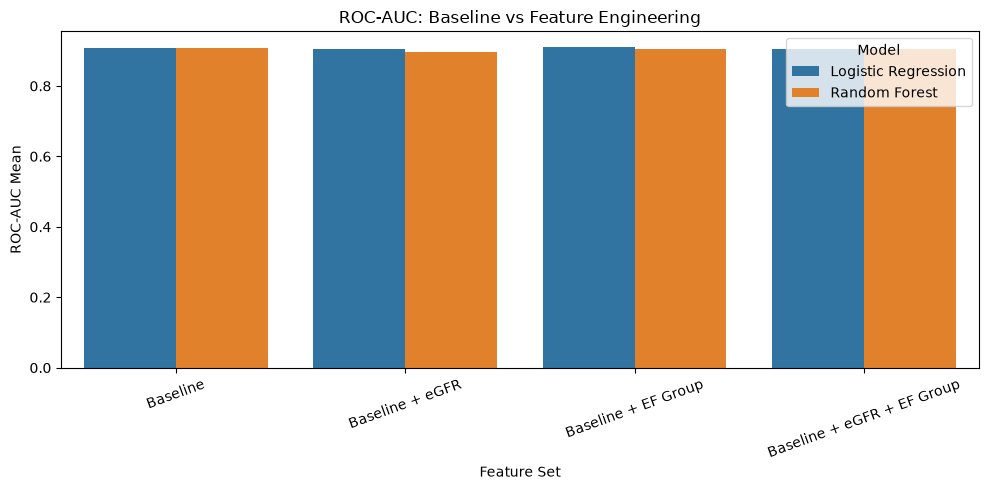

In [51]:
plt.figure(figsize=(10, 5))

sns.barplot(
    data=results_df,
    x="Feature Set",
    y="ROC-AUC Mean",
    hue="Model"
)

plt.xticks(rotation=20)
plt.title("ROC-AUC: Baseline vs Feature Engineering")
plt.tight_layout()
plt.show()

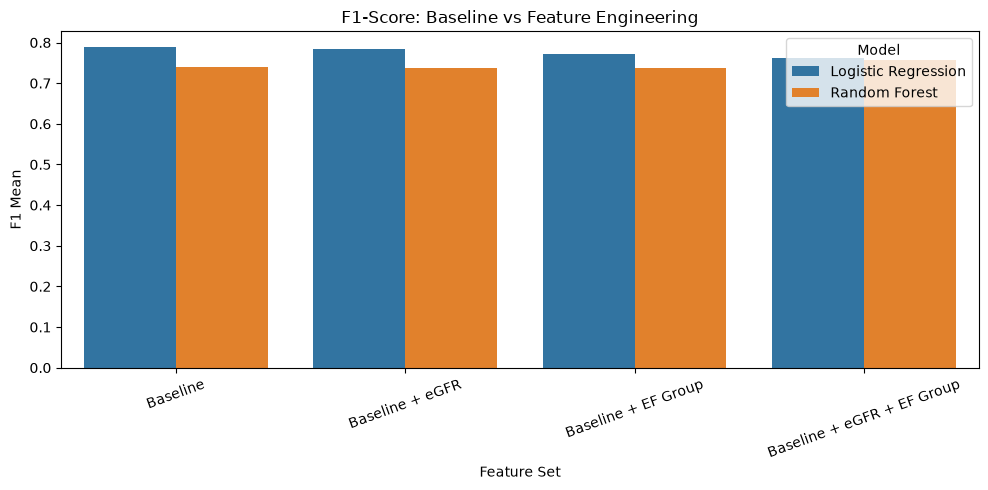

In [52]:
plt.figure(figsize=(10, 5))

sns.barplot(
    data=results_df,
    x="Feature Set",
    y="F1 Mean",
    hue="Model"
)

plt.xticks(rotation=20)
plt.title("F1-Score: Baseline vs Feature Engineering")
plt.tight_layout()
plt.show()